### Quantitative Analyse der sechs Wahlprogramme

---

#### 1. Datensatz einlesen und aufbereiten

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
# Datei einlesen
df = pd.read_parquet("all_parties_text_combined_prep.parquet")

# Erste Zeilen anzeigen
df.head()


,Party,Chapter,These,Text,Text_no_stopwords,These_no_stopwords,Text_lemmatized,These_lemmatized,These_unique_words
0,spd,Worauf es jetzt ankommt,None,Am 23. Februar findet die vorgezogene Bundesta...,februar findet vorgezogene bundestagswahl stat...,,Februar finden vorgezogen Bundestagswahl statt...,,
1,spd,Ein neuer Aufschwung für Deutschland,None,Viele Menschen machen sich derzeit Sorgen um d...,viele menschen derzeit sorgen wirtschaft land ...,,vieler Mensch derzeit sorgen Wirtschaft Land s...,,
2,spd,1. Wir kämpfen für neues Wachstum und sichere ...,None,"Dies ist das erste, aber sicher nicht das letz...",erste sicher letzte mal wörter kämpfen verwend...,,erster sicher letzter Mal wort kämpfen verwend...,,
3,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un...",brauchen bezahlbare energie geht unternehmen d...,energiepreise senken zentrale erfolgsbranchen ...,brauchen bezahlbar Energie gehen Unternehmen D...,Energiepreise senken zentral erfolgsbranche st...,Energiepreise senken zentral erfolgsbranche st...
4,spd,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...,tun unternehmen wirtschaftsstandort schaffen d...,unternehmen besten rahmenbedingungen deutschla...,tun Unternehmen Wirtschaftsstandort schaffen D...,Unternehmen gut Rahmenbedingung Deutschland in...,Unternehmen gut Rahmenbedingung Deutschland in...


In [19]:
print(len(df))

625


In [20]:
# Kopie des ursprünglichen Dataframes anlegen
df_modified = df.copy()

# Leere Zeilen entfernen
df_modified = df_modified[df_modified["These"].notna()]
print(len(df_modified))
df_modified.head()

564


,Party,Chapter,These,Text,Text_no_stopwords,These_no_stopwords,Text_lemmatized,These_lemmatized,These_unique_words
3,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un...",brauchen bezahlbare energie geht unternehmen d...,energiepreise senken zentrale erfolgsbranchen ...,brauchen bezahlbar Energie gehen Unternehmen D...,Energiepreise senken zentral erfolgsbranche st...,Energiepreise senken zentral erfolgsbranche st...
4,spd,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...,tun unternehmen wirtschaftsstandort schaffen d...,unternehmen besten rahmenbedingungen deutschla...,tun Unternehmen Wirtschaftsstandort schaffen D...,Unternehmen gut Rahmenbedingung Deutschland in...,Unternehmen gut Rahmenbedingung Deutschland in...
5,spd,1. Wir kämpfen für neues Wachstum und sichere ...,Wir wollen Bürokratie abbauen und Verfahren be...,Damit unsere Wirtschaft wieder schnell in Schw...,wirtschaft schnell schwung kommt müssen viele ...,bürokratie abbauen verfahren beschleunigen,Wirtschaft schnell Schwung kommen müssen viele...,Bürokratie abbauen Verfahren beschleunigen,Bürokratie abbauen Verfahren beschleunigen
6,spd,1. Wir kämpfen für neues Wachstum und sichere ...,"Wir wollen Innovationen ermöglichen, die Deuts...",Der viel beschworene Erfndergeist in Deutschla...,beschworene erfndergeist deutschland obersten ...,innovationen ermöglichen deutschland voranbringen,beschworen Erfndergeist Deutschland oberer Pri...,Innovation ermöglichen Deutschland voranbringen,Innovation ermöglichen Deutschland voranbringen
8,spd,2. Wir kämpfen für Made in Germany 2.0.,"Wir wollen eine stabile, breit aufgestellte un...","Unsere Unternehmen müssen sicher sein, dass si...",unternehmen müssen sicher klimaneutralität wei...,stabile breit aufgestellte zukunftsfähige wirt...,Unternehmen müssen sicher Klimaneutralität wei...,stabil breit aufgestellt zukunftsfähig Wirtschaft,stabil breit aufgestellt zukunftsfähig Wirtschaft


#### 2. Wortanzahl

In [21]:
# wird nicht benötigt, da zuvor die Zeilen mit leeren Thesen eliiniert wurden
# Fehlende Werte durch leere Strings ersetzen, um Fehler zu vermeiden
# df_modified["These"] = df_modified["These"].fillna("")
# df_modified["Text"] = df_modified["Text"].fillna("")

# Wortanzahl in den Spalten berechnen
df_modified["These_Word_Count"] = df_modified["These"].str.split().str.len()
df_modified["Text_Word_Count"] = df_modified["Text"].str.split().str.len()
df_modified["Total_Word_Count"] = df_modified["These"].str.split().str.len() + df_modified["Text"].str.split().str.len()

# Gruppieren nach 'Party' und Summen berechnen
word_counts = df_modified.groupby("Party")[["These_Word_Count", "Text_Word_Count", "Total_Word_Count"]].sum()

# Ergebnis ausgeben
print(word_counts)
print("\n")

# Durchschnittliche Wortanzahl pro Text berechnen
average_text_word_count = df_modified["Text_Word_Count"].mean()


print("Die maximale Wortanzahl pro These beträgt:", max(df_modified["These_Word_Count"]))
print("Die maximale Wortanzahl pro Text beträgt:", max(df_modified["Text_Word_Count"]))
print("Die durchschnittliche Wortanzahl pro Text beträgt:", round(average_text_word_count, 2))


        These_Word_Count  Text_Word_Count  Total_Word_Count
Party                                                      
afd                  381            19015             19396
cdu                  453            20559             21012
fdp                  640            16636             17276
gruene               738            11851             12589
linke                340            20104             20444
spd                  597            21205             21802


Die maximale Wortanzahl pro These beträgt: 22
Die maximale Wortanzahl pro Text beträgt: 1087
Die durchschnittliche Wortanzahl pro Text beträgt: 193.92


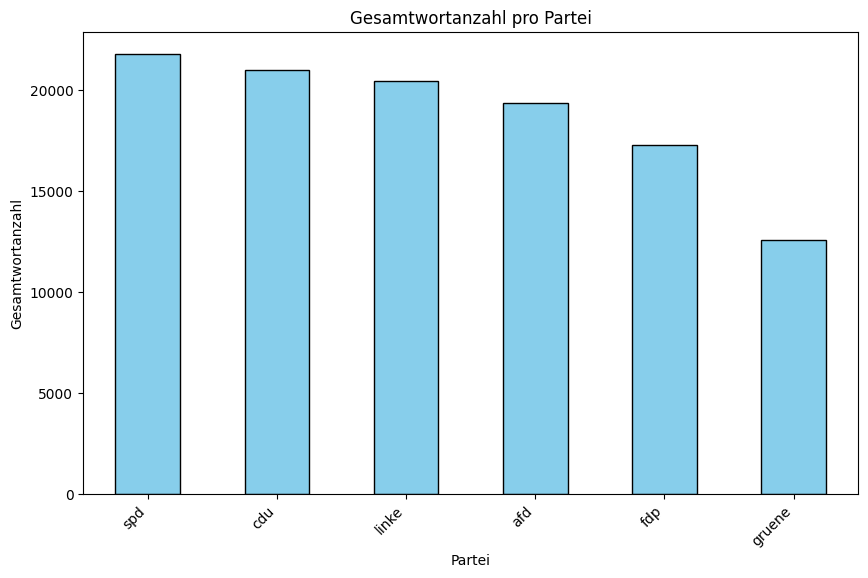

In [22]:
# Sortiere die Parteien nach der Gesamtwortanzahl absteigend
word_counts = word_counts.sort_values("Total_Word_Count", ascending=False)

# Balkendiagramm erstellen
plt.figure(figsize=(10, 6))
word_counts["Total_Word_Count"].plot(kind="bar", color="skyblue", edgecolor="black")

# Achsentitel und Diagrammtitel hinzufügen
plt.xlabel("Partei")
plt.ylabel("Gesamtwortanzahl")
plt.title("Gesamtwortanzahl pro Partei")

# Achsbeschriftungen drehen für bessere Lesbarkeit
plt.xticks(rotation=45, ha="right")

# Diagramm anzeigen
plt.show()

#### 3. Satzanzahl

In [23]:
# Anzahl der Wörter pro Text berechnen
df_modified['Text_Word_Count'] = df_modified['Text'].str.split().str.len()

# Gesamtanzahl der Wörter pro Partei berechnen
gesamt_woerter_pro_party = df_modified.groupby('Party')['Text_Word_Count'].sum().reset_index(name='gesamt_woerter')

# Anzahl der Sätze in der Spalte 'text' zählen
anzahl_saetze_text = df_modified.groupby('Party')['Text'].apply(
    lambda x: x.str.cat(sep=' ').count('.') + x.str.cat(sep=' ').count('!') + x.str.cat(sep=' ').count('?')
).reset_index(name='anzahl_saetze')

# Beide DataFrames zusammenführen
result = gesamt_woerter_pro_party.merge(anzahl_saetze_text, on='Party')

# Durchschnittliche Wörter pro Satz berechnen (Division durch 0 vermeiden)
result['durchschn_woerter_pro_satz'] = result['gesamt_woerter'] / result['anzahl_saetze'].replace(0, 1)

print(result)


    Party  gesamt_woerter  anzahl_saetze  durchschn_woerter_pro_satz
0     afd           19015           1263                   15.055424
1     cdu           20559           1970                   10.436041
2     fdp           16636           1152                   14.440972
3  gruene           11851            742                   15.971698
4   linke           20104           1453                   13.836201
5     spd           21205           1348                   15.730712


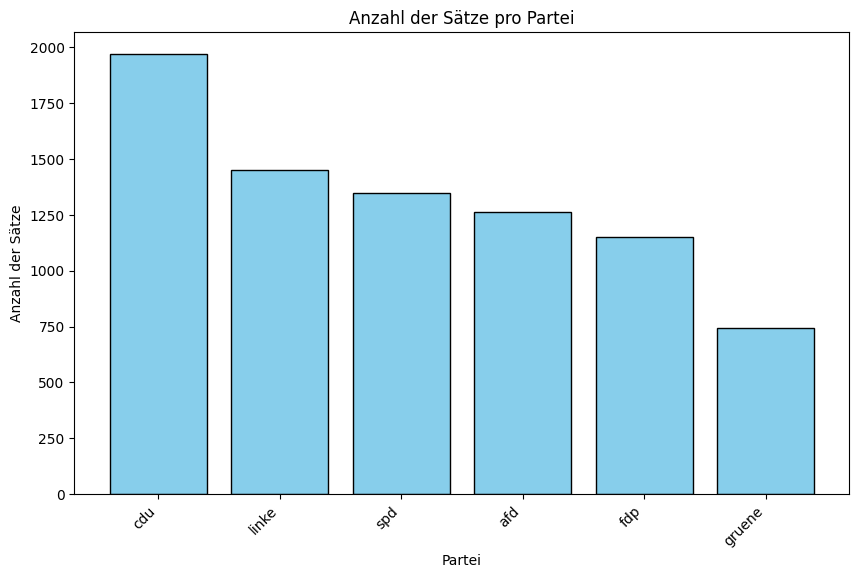

In [24]:
# Sortiere die Parteien nach der Satzanzahl absteigend
result = result.sort_values("anzahl_saetze", ascending=False)

# Balkendiagramm erstellen
plt.figure(figsize=(10, 6))
plt.bar(result["Party"], result["anzahl_saetze"], color="skyblue", edgecolor="black")

# Achsentitel und Diagrammtitel hinzufügen
plt.xlabel("Partei")
plt.ylabel("Anzahl der Sätze")
plt.title("Anzahl der Sätze pro Partei")

# Achsbeschriftungen drehen für bessere Lesbarkeit
plt.xticks(rotation=45, ha="right")

# Diagramm anzeigen
plt.show()

#### 4. Word-Clouds

In [25]:
from wordcloud import WordCloud
import spacy
from spacy.lang.de.stop_words import STOP_WORDS
from collections import Counter

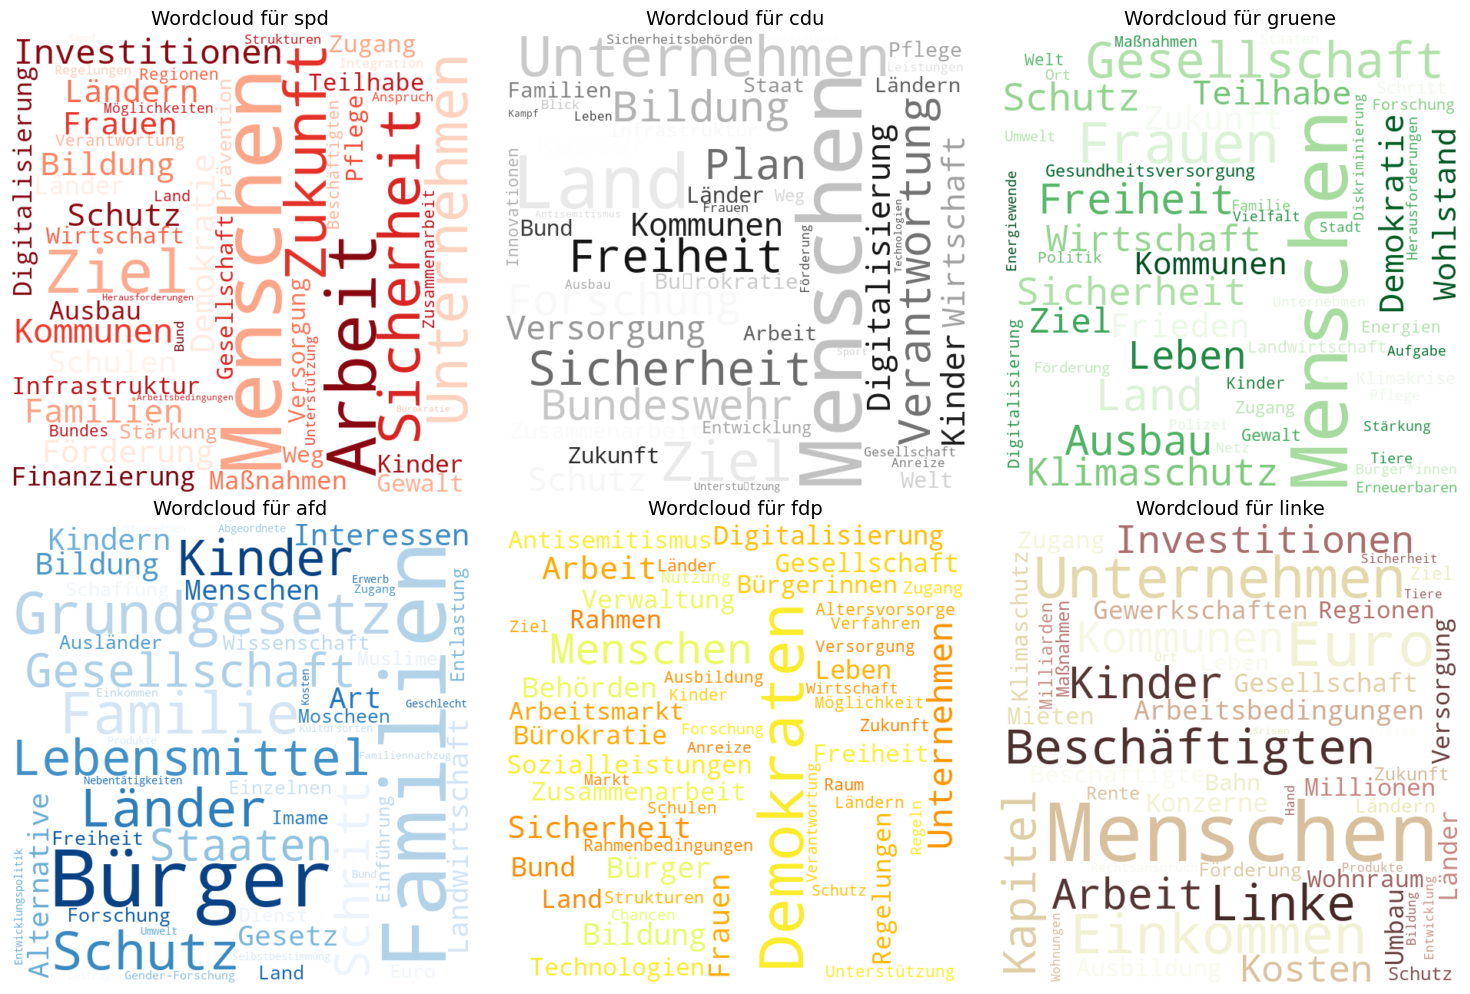

In [26]:
# Lade das deutsche Sprachmodell für die POS-Tagging-Analyse
nlp = spacy.load("de_core_news_md")

# Stopwords erweitern
additional_stopwords = {
    "prozent"
}  # Eigene Stopwords hier hinzufügen
stopwords = STOP_WORDS.union(additional_stopwords)

def extract_nouns(text):
    """Extrahiert alle Substantive aus einem Text (inkl. Original-Schreibweise)."""
    doc = nlp(text)  # Verarbeite den Text mit spaCy
    nouns = [token.text for token in doc if token.pos_ == "NOUN" and token.text.lower() not in stopwords]
    return nouns

# Parteien extrahieren
parties = df_modified['Party'].unique()
num_parties = len(parties)

# Matplotlib-Subplots für 2x3-Grid erstellen
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 Zeilen, 3 Spalten, große Figur
axes = axes.flatten()  # Damit wir einfach auf jedes Subplot zugreifen können

# Liste der gezielten Farbschemata
colormaps = ['Reds', 'Greys', 'Greens', 'Blues', 'Wistia_r', 'pink_r']  # Rot, Schwarz, Grün, Blau, Gelb, Dunkelrot

# Wordclouds für jede Partei generieren und im Raster anzeigen
for i, party in enumerate(parties):
    # Texte aus den Spalten "These" und "Text" zusammenfügen
    group = df_modified[df_modified['Party'] == party]
    text_data = " ".join(group['These'].astype(str)) + " " + " ".join(group['Text'].astype(str))
    
    # Nur Substantive extrahieren
    nouns_only = extract_nouns(text_data)

    # Häufigkeiten zählen und die 50 häufigsten Wörter auswählen
    noun_freq = Counter(nouns_only)
    most_common_nouns = dict(noun_freq.most_common(50))  # Maximal 50 häufigste Wörter

    # Wordcloud erstellen mit dem gezielten Farbschema
    wordcloud = WordCloud(width=600, height=600, background_color='white', 
                          colormap=colormaps[i],  # Verwende gezielte Farbschemata
                          random_state=310  # Fixiert die zufällige Platzierung der Wörter
                          ).generate_from_frequencies(most_common_nouns)

    # Wordcloud im Raster anzeigen
    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"Wordcloud für {party}", fontsize=14)

# Falls weniger als 6 Parteien, leere Subplots entfernen
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Layout optimieren
plt.show()


#### 5. Verben

In [ ]:
from collections import Counter

In [27]:
def extract_verbs(text):
    """Extrahiert alle Verben aus einem Text und gibt sie in ihrer Grundform zurück."""
    doc = nlp(text)  # Verarbeite den Text mit spaCy
    verbs = [token.lemma_ for token in doc if token.pos_ == "VERB"]  # Nur Verben in Grundform
    return verbs

# Dictionary für die häufigsten Verben pro Partei
common_verbs_by_party = {}

# Alle Verben nach Partei sammeln
for party in df_modified['Party'].unique():
    party_verbs = []

    # Filtere die Daten für die aktuelle Partei
    party_data = df_modified[df_modified['Party'] == party]
    
    for index, row in party_data.iterrows():
        text_data = row['These'] + " " + row['Text']  # Kombiniere These und Text
        verbs = extract_verbs(text_data)
        party_verbs.extend(verbs)

    # Häufigkeiten zählen und die 10 häufigsten Verben auswählen
    verb_freq = Counter(party_verbs)
    common_verbs_by_party[party] = verb_freq.most_common(10)  # Maximal 10 häufigste Verben

# Ausgabe der häufigsten Verben gruppiert nach Partei
for party, verbs in common_verbs_by_party.items():
    print(f"\nHäufigste Verben für {party}:")
    for verb, freq in verbs:
        print(f"{verb}: {freq}")


Häufigste Verben für spd:
stärken: 82
setzen: 76
unterstützen: 62
schaffen: 53
fördern: 52
machen: 48
brauchen: 34
ermöglichen: 32
sorgen: 32
geben: 30

Häufigste Verben für cdu:
stärken: 107
setzen: 90
machen: 68
unterstützen: 56
schaffen: 53
brauchen: 45
geben: 40
fördern: 37
sorgen: 36
stellen: 32

Häufigste Verben für gruene:
setzen: 39
machen: 38
schaffen: 35
stärken: 35
sorgen: 30
brauchen: 26
gehören: 22
gehen: 22
ermöglichen: 22
schützen: 22

Häufigste Verben für afd:
fordern: 103
lehnen: 69
treten: 56
setzen: 50
erhalten: 40
bleiben: 27
beenden: 27
haben: 27
fördern: 26
abschaffen: 26

Häufigste Verben für fdp:
setzen: 62
stärken: 56
schaffen: 45
brauchen: 41
ermöglichen: 40
machen: 39
fordern: 37
erhalten: 21
lehnen: 21
verbessern: 20

Häufigste Verben für linke:
fordern: 88
brauchen: 70
setzen: 39
stärken: 36
machen: 32
haben: 31
geben: 30
verbieten: 27
fördern: 27
schaffen: 23


In [ ]:
# Dictionary für die häufigsten Verben pro Partei
common_verbs_by_party = {}

# Globaler Counter für die häufigsten Verben insgesamt
global_verb_counter = Counter()

# Alle Verben nach Partei sammeln
for party in df_modified['Party'].unique():
    party_verbs = []

    # Filtere die Daten für die aktuelle Partei
    party_data = df_modified[df_modified['Party'] == party]
    
    for index, row in party_data.iterrows():
        text_data = row['These'] + " " + row['Text']  # Kombiniere These und Text
        verbs = extract_verbs(text_data)
        party_verbs.extend(verbs)

        # Füge die Verben zum globalen Zähler hinzu
        global_verb_counter.update(verbs)

    # Häufigkeiten zählen und die 10 häufigsten Verben auswählen
    verb_freq = Counter(party_verbs)
    common_verbs_by_party[party] = verb_freq.most_common(10)  # Maximal 10 häufigste Verben

# Ausgabe der häufigsten Verben gruppiert nach Partei
for party, verbs in common_verbs_by_party.items():
    print(f"\nHäufigste Verben für {party}:")
    for verb, freq in verbs:
        print(f"{verb}: {freq}")

# Ausgabe der 10 häufigsten Verben insgesamt
print("\nHäufigste Verben insgesamt:")
for verb, freq in global_verb_counter.most_common(10):
    print(f"{verb}: {freq}")



Häufigste Verben für spd:
stärken: 82
setzen: 76
unterstützen: 62
schaffen: 53
fördern: 52
machen: 48
brauchen: 34
ermöglichen: 32
sorgen: 32
geben: 30

Häufigste Verben für cdu:
stärken: 107
setzen: 90
machen: 68
unterstützen: 56
schaffen: 53
brauchen: 45
geben: 40
fördern: 37
sorgen: 36
stellen: 32

Häufigste Verben für gruene:
setzen: 39
machen: 38
schaffen: 35
stärken: 35
sorgen: 30
brauchen: 26
gehören: 22
gehen: 22
ermöglichen: 22
schützen: 22

Häufigste Verben für afd:
fordern: 103
lehnen: 69
treten: 56
setzen: 50
erhalten: 40
bleiben: 27
beenden: 27
haben: 27
fördern: 26
abschaffen: 26

Häufigste Verben für fdp:
setzen: 62
stärken: 56
schaffen: 45
brauchen: 41
ermöglichen: 40
machen: 39
fordern: 37
erhalten: 21
lehnen: 21
verbessern: 20

Häufigste Verben für linke:
fordern: 88
brauchen: 70
setzen: 39
stärken: 36
machen: 32
haben: 31
geben: 30
verbieten: 27
fördern: 27
schaffen: 23

Häufigste Verben insgesamt:
setzen: 356
stärken: 340
fordern: 242
machen: 239
brauchen: 226
sch

#### 6. Themenanalyse mittels Manifestoberta

57 Manifestoberta Kategorien (https://manifesto-project.wzb.eu/coding_schemes/mp_v4)

Definition von gegenteiligen Paaren und ähnlichen Gruppen siehe "adjazenzmatrix.ipynb"

| Code | Beschreibung                               |
| ---- | ------------------------------------------ |
| 101  | Foreign Special Relationships: Positive    |
| 102  | Foreign Special Relationships: Negative    |
| 103  | Anti-Imperialism                           |
| 104  | Military: Positive                         |
| 105  | Military: Negative                         |
| 106  | Peace                                      |
| 107  | Internationalism: Positive                 |
| 108  | European Community/Union: Positive         |
| 109  | Internationalism: Negative                 |
| 110  | European Community/Union: Negative         |
| 201  | Freedom and Human Rights                   |
| 202  | Democracy                                  |
| 203  | Constitutionalism: Positive                |
| 204  | Constitutionalism: Negative                |
| 301  | Decentralization                           |
| 302  | Centralisation                             |
| 303  | Governmental and Administrative Efficiency |
| 304  | Political Corruption                       |
| 305  | Political Authority                        |
| 401  | Free Market Economy                        |
| 402  | Incentives: Positive                       |
| 403  | Market Regulation                          |
| 404  | Economic Planning                          |
| 405  | Corporatism/Mixed Economy                  |
| 406  | Protectionism: Positive                    |
| 407  | Protectionism: Negative                    |
| 408  | Economic Goals                             |
| 409  | Keynesian Demand Management                |
| 409  | Keynesian Demand Management                |
| 410  | Economic Growth: Positive                  |
| 411  | Technology and Infrastructure: Positive    |
| 412  | Controlled Economy                         |
| 413  | Nationalisation                            |
| 414  | Economic Orthodoxy                         |
| 415  | Marxist Analysis                           |
| 416  | Anti-Growth Economy: Positive              |
| 501  | Environmental Protection: Positive         |
| 502  | Culture: Positive                          |
| 503  | Equality: Positive                         |
| 504  | Welfare State Expansion                    |
| 505  | Welfare State Limitation                   |
| 506  | Education Expansion                        |
| 507  | Education Limitation                       |
| 601  | National Way of Life: Positive             |
| 602  | National Way of Life: Negative             |
| 603  | Traditional Morality: Positive             |
| 604  | Traditional Morality: Negative             |
| 605  | Law and Order: Positive                    |
| 606  | Civic Mindedness: Positive                 |
| 607  | Multiculturalism: Positive                 |
| 608  | Multiculturalism: Negative                 |
| 701  | Labour Groups: Positive                    |
| 702  | Labour Groups: Negative                    |
| 703  | Agriculture and Farmers: Positive          |
| 704  | Middle Class and Professional Groups       |
| 705  | Underprivileged Minority Groups            |
| 706  | Non-economic Demographic Groups            |

##### 6.1 Wahlprogramme

In [30]:
import ipywidgets as widgets
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import seaborn as sns

In [31]:
# Lade das Modell und den Tokenizer
model = AutoModelForSequenceClassification.from_pretrained("manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

# Funktion zur Klassifizierung eines Satzes mit Kontext
def classify_row(row):
    sentence = row['These']
    context = row['Text']
    
    # Überprüfen, ob der Satz und der Kontext gültig sind
    if pd.isna(sentence) or pd.isna(context) or sentence.strip() == "" or context.strip() == "":
        return None  # Rückgabe von None, wenn der Satz oder der Kontext nicht gültig ist

    inputs = tokenizer(sentence,
                       context,
                       return_tensors="pt",
                       max_length=512,
                       padding="max_length",
                       truncation=True)

    logits = model(**inputs).logits
    predicted_class = model.config.id2label[logits.argmax().item()]
    
    return predicted_class

# Neue Spalte für die vorhergesagte Klasse erstellen
df_modified['Predicted_Class'] = df_modified.apply(classify_row, axis=1)

# Ausgabe der Thesen mit Zuordnung
df_modified[['Party','These', 'Text', 'Predicted_Class']]


,Party,These,Text,Predicted_Class
3,spd,Wir wollen Energiepreise senken und zentrale E...,"Wir brauchen bezahlbare Energie, sonst geht un...",402 - Incentives
4,spd,"Wir wollen, dass Unternehmen die besten Rahmen...",Wir können etwas tun für unsere Unternehmen un...,402 - Incentives
5,spd,Wir wollen Bürokratie abbauen und Verfahren be...,Damit unsere Wirtschaft wieder schnell in Schw...,303 - Governmental and Administrative Efficiency
6,spd,"Wir wollen Innovationen ermöglichen, die Deuts...",Der viel beschworene Erfndergeist in Deutschla...,411 - Technology and Infrastructure
8,spd,"Wir wollen eine stabile, breit aufgestellte un...","Unsere Unternehmen müssen sicher sein, dass si...",408 - Economic Goals
...,...,...,...,...
618,linke,Niemand flieht freiwillig,Das Chaos an den europäischen Grenzen ist das ...,201 - Freedom and Human Rights
619,linke,Wir sind eine Einwanderungsgesellschaft – und ...,Die großen Herausforderungen von mehr Personal...,607 - Multiculturalism: Positive
622,linke,Kultur – vielfältig und für alle zugänglich,Der Zugang zu Kultur soll nicht vom Geldbeutel...,503 - Equality: Positive
623,linke,Sport ist kein Luxus,Sport ist für alle da. Dafür müssen die Zugang...,503 - Equality: Positive


In [32]:
# ggf. Ausgabe als CSV-Datei
# df_modified.to_csv("all_parties_text_combined_classified.csv", index=False, encoding="utf-8-sig")

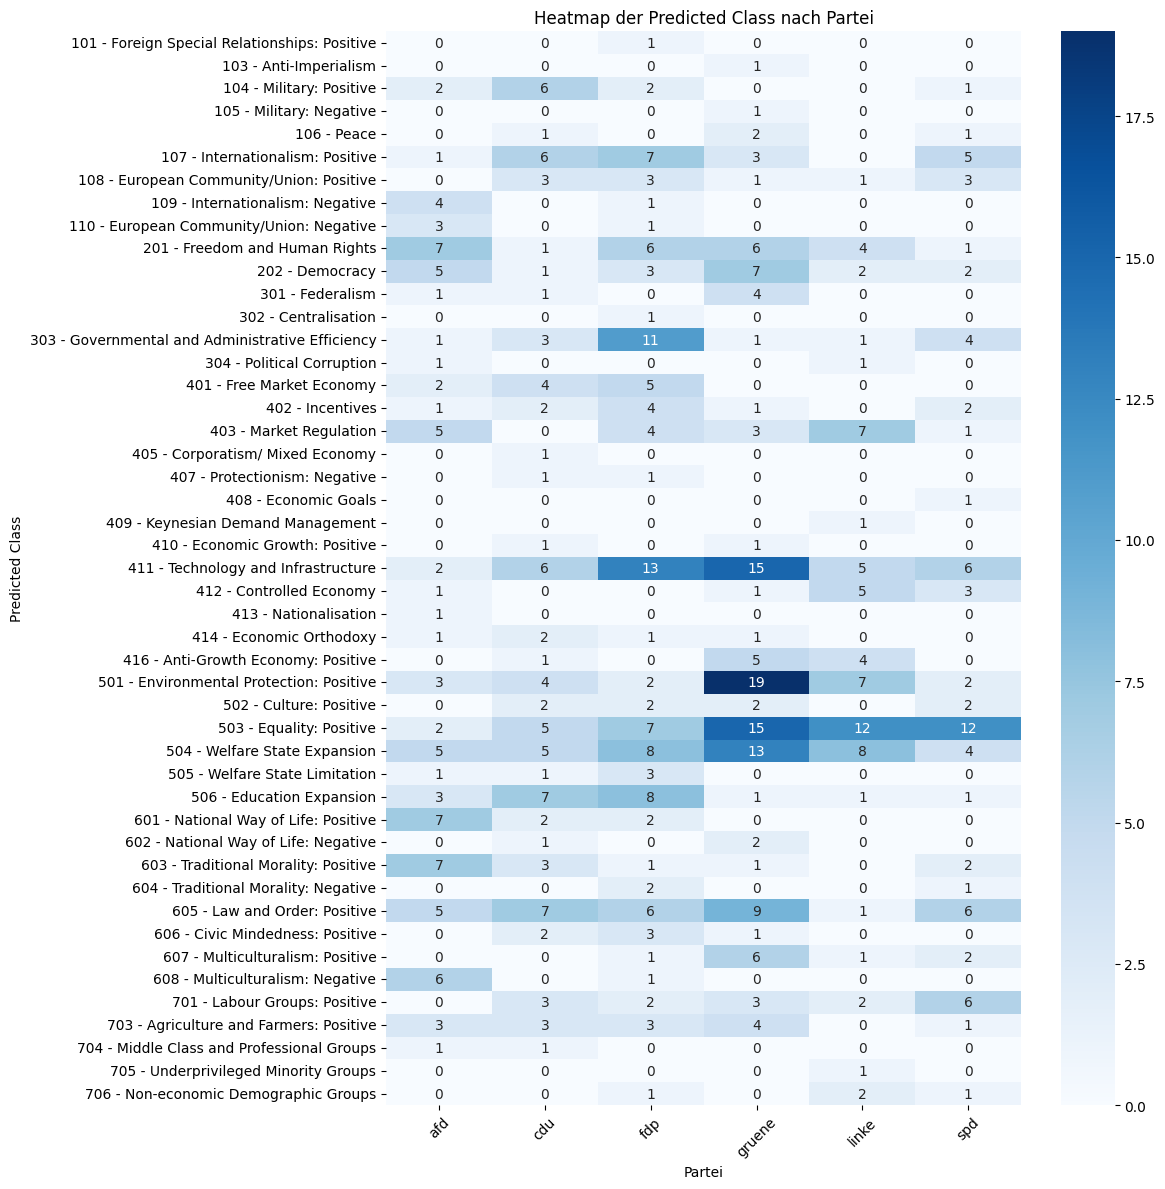

In [33]:
# Erstelle das Pivot-Table
pivot_table = df_modified.pivot_table(
    index='Predicted_Class',  # Zeilen: Ausprägung aus der Spalte Predicted_Class
    columns='Party',          # Spalten: Parteien aus der Spalte Party
    aggfunc='size',           # Aggregationsfunktion: Anzahl der Vorkommen
    fill_value=0              # Fehlende Werte mit 0 füllen
)

# Heatmap erstellen
plt.figure(figsize=(12, 12))  # Größe der Heatmap anpassen
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='Blues', cbar=True)  # cbar zeigt die Farbskala
plt.title('Heatmap der Predicted Class nach Partei')
plt.xlabel('Partei')
plt.ylabel('Predicted Class')
plt.xticks(rotation=45)  # Rotieren der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.tight_layout()  # Layout optimieren
plt.show()


In [34]:
# Ausgabe der klassifizierten Thesen als parquet-Datei
df_modified.to_parquet("all_parties_text_combined_prep_classified.parquet", engine="pyarrow")

##### 6.2 Wahl-O-Mat-Thesen

In [35]:
df_wahlomat = pd.read_parquet("wahlomat_thesen_prep.parquet")
df_wahlomat.head()

,These,These_no_stopwords,These_lemmatized,These_unique_words,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,beschäftigten sollen bereits 40 beitragsjahren...,beschäftigter sollen bereits 40 beitragsjahr a...,beschäftigter sollen bereits 40 beitragsjahr a...,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,bürgerinnen bürger sollen gesetzlichen kranken...,bürgerinn Bürger sollen gesetzlich Krankenkass...,bürgerinn Bürger sollen gesetzlich Krankenkass...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
2,An Bahnhöfen soll die Bundespolizei Software z...,bahnhöfen bundespolizei software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu
3,Asylsuchende sollen in Deutschland sofort nach...,asylsuchende sollen deutschland sofort antrags...,asylsuchender sollen Deutschland sofort Antrag...,asylsuchender sollen Deutschland sofort Antrag...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,neutral
4,"Asylsuchende, die über einen anderen EU-Staat ...",asylsuchende eingereist sollen deutschen grenz...,asylsuchender einreisen sollen deutsch Grenze ...,asylsuchender einreisen sollen deutsch Grenze ...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu


In [36]:
# Wortanzahl in den Thesen berechnen
df_wahlomat["These_Word_Count_Wahlomat"] = df_wahlomat["These"].str.split().str.len()
print("Die maximale Wortanzahl pro These beträgt:", max(df_wahlomat["These_Word_Count_Wahlomat"]))

Die maximale Wortanzahl pro These beträgt: 17


##### 6.2 Thesen des Wahl-O-Mat klassifizieren

In [37]:
# Lade das Modell und den Tokenizer
model = AutoModelForSequenceClassification.from_pretrained("manifesto-project/manifestoberta-xlm-roberta-56policy-topics-sentence-2024-1-1")
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

# Funktion zur Klassifizierung einer Zeile
def classify_thesis(thesis):
    inputs = tokenizer(thesis,
                       return_tensors="pt",
                       max_length=20, # maximale Wortanzahl der Wahlomat Thesen beträgt 17
                       padding="max_length",
                       truncation=True)

    logits = model(**inputs).logits
    predicted_class = model.config.id2label[logits.argmax().item()]
    return predicted_class

# Neue Spalte für die vorhergesagte Klasse erstellen
df_wahlomat['Predicted_Class'] = df_wahlomat['These'].apply(classify_thesis)

# Ausgabe der ersten Thesen mit Zuordnung
df_wahlomat[['These', 'Predicted_Class']]

,These,Predicted_Class
0,Alle Beschäftigten sollen bereits nach 40 Beit...,504 - Welfare State Expansion
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,504 - Welfare State Expansion
2,An Bahnhöfen soll die Bundespolizei Software z...,605 - Law and Order: Positive
3,Asylsuchende sollen in Deutschland sofort nach...,602 - National Way of Life: Negative
4,"Asylsuchende, die über einen anderen EU-Staat ...",705 - Underprivileged Minority Groups
5,Auf allen Autobahnen soll ein generelles Tempo...,411 - Technology and Infrastructure
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,107 - Internationalism: Positive
7,Bei Neuvermietungen sollen die Mietpreise weit...,412 - Controlled Economy
8,Bei der Besteuerung von Einkommen soll der Spi...,503 - Equality: Positive
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,411 - Technology and Infrastructure


In [38]:
# Klassifizierung von Thesen zum Thema "Energie" nicht aussagekräftig, da es keine Kategorie "Environmental Protection: Negative" gibt
df_wahlomat[df_wahlomat['Predicted_Class'] == '501 - Environmental Protection: Positive']

,These,These_no_stopwords,These_lemmatized,These_unique_words,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP,These_Word_Count_Wahlomat,Predicted_Class
12,Der Ausbau erneuerbarer Energien soll weiterhi...,ausbau erneuerbarer energien weiterhin staat f...,Ausbau erneuerbar Energie weiterhin Staat fina...,Ausbau erneuerbar Energie weiterhin Staat fina...,stimme zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,11,501 - Environmental Protection: Positive
17,"Deutschland soll das Ziel verwerfen, klimaneut...",deutschland ziel verwerfen klimaneutral,Deutschland Ziel verwerfen klimaneutral,Deutschland Ziel verwerfen klimaneutral,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu,8,501 - Environmental Protection: Positive
27,Für die Stromerzeugung soll Deutschland wieder...,stromerzeugung deutschland kernenergie nutzen,Stromerzeugung Deutschland Kernenergie nutzen,Stromerzeugung Deutschland Kernenergie nutzen,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu,8,501 - Environmental Protection: Positive
33,Neue Heizungen sollen auch zukünftig vollständ...,neue heizungen sollen zukünftig vollständig fo...,neu Heizung sollen zukünftig vollständig fossi...,neu Heizung sollen zukünftig vollständig fossi...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu,17,501 - Environmental Protection: Positive


In [39]:
# Anzahl der Ausprägungen von 'Predicted_Class' zählen
class_counts = df_wahlomat['Predicted_Class'].value_counts()

# Ausgabe der Anzahl der Ausprägungen
print(class_counts)

Predicted_Class
501 - Environmental Protection: Positive    4
503 - Equality: Positive                    3
411 - Technology and Infrastructure         3
412 - Controlled Economy                    2
504 - Welfare State Expansion               2
606 - Civic Mindedness: Positive            2
202 - Democracy                             2
701 - Labour Groups: Positive               2
605 - Law and Order: Positive               2
505 - Welfare State Limitation              1
107 - Internationalism: Positive            1
602 - National Way of Life: Negative        1
705 - Underprivileged Minority Groups       1
110 - European Community/Union: Negative    1
104 - Military: Positive                    1
407 - Protectionism: Negative               1
302 - Centralisation                        1
403 - Market Regulation                     1
414 - Economic Orthodoxy                    1
402 - Incentives                            1
204 - Constitutionalism: Negative           1
607 - Multicultura

In [40]:
# Ausgabe der klassifizierten Thesen als parquet-Datei
df_wahlomat.to_parquet("wahlomat_thesen_positionen_classified.parquet", engine="pyarrow")